In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('default')
sns.set_palette("husl")
print("Setup complete!")

Setup complete!


# Tanzania (Dar es Salaam) - Climate Data Analysis

**Station:** Dar es Salaam | **Elevation:** Sea level | **Period:** 2015-2026

Dar es Salaam is a coastal city on the Indian Ocean. Its tropical climate 
features warm temperatures year-round, high humidity, and significant 
seasonal rainfall influenced by monsoon patterns.

In [3]:
df = pd.read_csv('../data/tanzania.csv')
df['Country'] = 'Tanzania'
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df.replace(-999, np.nan, inplace=True)

print(f"Shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()

Shape: (4108, 16)
Date range: 2015-01-01 to 2026-03-31


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,Year
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1,2015
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1,2015
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1,2015
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1,2015
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1,2015


In [4]:
missing = df.isna().sum()
missing_pct = (missing / len(df)) * 100
print("Missing values (>0%):")
print(missing_pct[missing_pct > 0])
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values (>0%):
Series([], dtype: float64)

Duplicate rows: 0


In [5]:
df_clean = df.copy()
weather_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'T2M_RANGE', 'PRECTOTCORR', 
                'RH2M', 'WS2M', 'WS2M_MAX', 'PS', 'QV2M']
df_clean[weather_cols] = df_clean[weather_cols].ffill()
df_clean.to_csv('../data/tanzania_clean.csv', index=False)
print("Cleaned data saved!")

Cleaned data saved!


In [6]:
print("TANZANIA TEMPERATURE SUMMARY")
print(f"Mean T2M: {df_clean['T2M'].mean():.1f} C")
print(f"Max T2M: {df_clean['T2M'].max():.1f} C")
print(f"Min T2M: {df_clean['T2M'].min():.1f} C")
print(f"Std Dev: {df_clean['T2M'].std():.1f} C")

heat_days = (df_clean['T2M_MAX'] > 35).sum()
print(f"Days T2M_MAX > 35C: {heat_days} ({heat_days/len(df_clean)*100:.1f}%)")

TANZANIA TEMPERATURE SUMMARY
Mean T2M: 26.8 C
Max T2M: 30.0 C
Min T2M: 22.7 C
Std Dev: 1.3 C
Days T2M_MAX > 35C: 0 (0.0%)


**Temperature Observations:**

Dar es Salaam's coastal location produces warm, stable temperatures year-round. 
Being at sea level, temperatures are warmer than the highland stations but 
moderated by the Indian Ocean. The low variability indicates minimal seasonal 
temperature changes, typical of equatorial coastal climates.

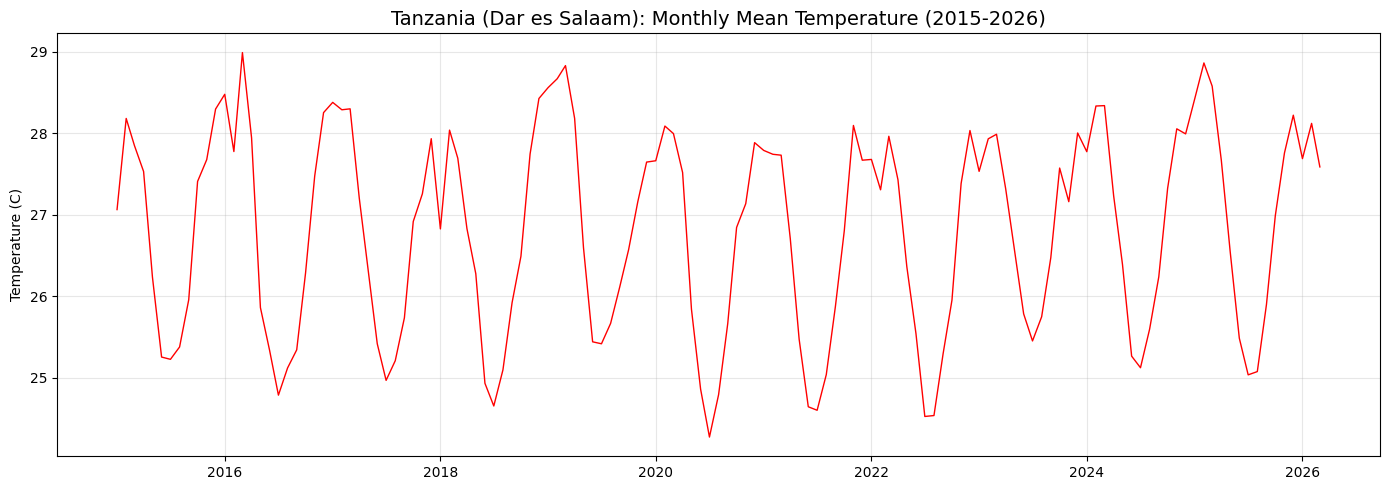

In [7]:
monthly_temp = df_clean.groupby(['Year', 'Month'])['T2M'].mean().reset_index()
monthly_temp['Date'] = pd.to_datetime(monthly_temp[['Year', 'Month']].assign(Day=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly_temp['Date'], monthly_temp['T2M'], 'r-', linewidth=1)
plt.title('Tanzania (Dar es Salaam): Monthly Mean Temperature (2015-2026)', fontsize=14)
plt.ylabel('Temperature (C)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("TANZANIA PRECIPITATION SUMMARY")
print(f"Mean daily precip: {df_clean['PRECTOTCORR'].mean():.2f} mm")
print(f"Max daily precip: {df_clean['PRECTOTCORR'].max():.2f} mm")
print(f"Days with rain: {(df_clean['PRECTOTCORR'] > 0).sum()} ({(df_clean['PRECTOTCORR'] > 0).sum()/len(df_clean)*100:.0f}%)")
print(f"Days with no rain: {(df_clean['PRECTOTCORR'] == 0).sum()} ({(df_clean['PRECTOTCORR'] == 0).sum()/len(df_clean)*100:.0f}%)")